# Evaluación Difusa de Riesgo Crediticio
## Sistema de Inferencia Colectiva — German Credit Dataset (UCI)

**Agentes difusos:** Mamdani · Tsukamoto · TSK (Takagi-Sugeno-Kang)  
**Solución global:** Ensamble simple + Ensamble por reputación de analista (BONUS)

---
### Descripción del Dataset
El **German Credit Dataset** (UCI ML Repository, id=144) contiene 1000 solicitudes de crédito  
con variables como duración, monto, historial crediticio, ahorro y empleo.  
Variable objetivo: **1 = Buen pagador (70%)**, **2 = Mal pagador (30%)**.

> *Reproducibilidad:* El dataset se genera programáticamente replicando la distribución  
> estadística del UCI original; resultados reproducibles con `seed=42`.

## 1. Dependencias e Importaciones

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Image, display
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
!pip install scikit-fuzzy
import skfuzzy as fuzz
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score,
                             roc_curve, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('✓ Librerías cargadas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 32.9 MB/s eta 0:00:00
✓ Librerías cargadas


## 2. Carga y Exploración del Dataset

El dataset replica la distribución conocida del UCI German Credit (id=144):
- **Duración:** 6–72 meses (modal: 12 meses)
- **Historial crediticio:** 0=sin créditos, 1=pagados, 2=existentes OK, 3=mora, 4=crítico
- **Ahorro:** 1=<100DM, 2=100–500, 3=500–1000, 4=>1000, 5=desconocido
- **Empleo:** 1=desempleado, 2=<1año, 3=1–4años, 4=4–7años, 5=>7años

In [2]:
n = 1000
d = {}
d['duration']       = np.random.choice([6,12,18,24,30,36,48,60,72], size=n,
                          p=[0.10,0.22,0.10,0.20,0.08,0.13,0.08,0.05,0.04])
d['credit_amount']  = np.random.lognormal(7.5, 0.7, n).astype(int).clip(250, 18000)
d['savings']        = np.random.choice([1,2,3,4,5], size=n, p=[0.60,0.10,0.06,0.06,0.18])
d['employment']     = np.random.choice([1,2,3,4,5], size=n, p=[0.07,0.17,0.34,0.17,0.25])
d['credit_history'] = np.random.choice([0,1,2,3,4], size=n, p=[0.04,0.05,0.53,0.09,0.29])
d['personal_status']= np.random.choice([1,2,3,4],   size=n, p=[0.05,0.31,0.55,0.09])
d['age']            = np.random.normal(35, 11, n).astype(int).clip(19, 75)

# Score de riesgo latente calibrado con la lógica del dataset original
risk_score  = (4 - d['credit_history'])          * 0.30
risk_score += (d['duration']  - 12) / 60          * 0.50
risk_score += (d['credit_amount'] - 1000) / 17000 * 0.40
risk_score += (5 - d['savings']) / 4               * 0.30
risk_score += (2.5 - d['employment']) / 4          * 0.20
risk_score += (19 - d['age']) / 56                 * 0.10
risk_score += np.random.normal(0, 0.25, n)
risk_score  = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())

d['risk']            = np.where(risk_score >= np.percentile(risk_score, 70), 2, 1)
d['risk_score_true'] = risk_score

df = pd.DataFrame(d)
print(f'Dataset: {df.shape}  |  Distribución: {dict(df["risk"].value_counts())}  (1=Bueno, 2=Malo)')
df.describe().round(2)

Dataset: (1000, 9)  |  Distribución: {1: np.int64(700), 2: np.int64(300)}  (1=Bueno, 2=Malo)


,duration,credit_amount,savings,employment,credit_history,personal_status,age,risk,risk_score_true
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,26.17,2454.44,2.09,3.33,2.53,2.68,34.34,1.30,0.42
std,16.85,1852.50,1.56,1.23,1.06,0.71,10.33,0.46,0.16
min,6.00,250.00,1.00,1.00,0.00,1.00,19.00,1.00,0.00
25%,12.00,1218.00,1.00,3.00,2.00,2.00,27.00,1.00,0.31
50%,24.00,1917.50,1.00,3.00,2.00,3.00,34.00,1.00,0.42
75%,36.00,3033.75,3.00,4.00,4.00,3.00,41.00,2.00,0.52
max,72.00,16901.00,5.00,5.00,4.00,4.00,69.00,2.00,1.00


## 3. Variables Difusas

Las 7 variables originales se reducen a **3 variables difusas**, todas orientadas de modo que  
**valor alto → mayor riesgo de impago**. Esto garantiza consistencia en las reglas SI-ENTONCES.

| Variable difusa | Fórmula | Significado |
|---|---|---|
| `riesgo_historico` | `(4 - credit_history) / 4` | 1.0 = peor historial |
| `carga_financiera` | `0.5·dur_norm + 0.5·mnt_norm` | 1.0 = mayor deuda |
| `instabilidad` | `1 - (0.5·sav_norm + 0.5·emp_norm)` | 1.0 = menos estable |

In [3]:
def build_features(df):
    X = pd.DataFrame()
    X['riesgo_historico'] = (4 - df['credit_history']) / 4.0
    dur_n = (df['duration'] - 6) / (72 - 6)
    mnt_n = (df['credit_amount'] - 250) / (18000 - 250)
    X['carga_financiera'] = 0.5 * dur_n + 0.5 * mnt_n
    sav_n = (df['savings'] - 1) / 4.0
    emp_n = (df['employment'] - 1) / 4.0
    X['instabilidad'] = 1.0 - (0.5 * sav_n + 0.5 * emp_n)
    return X.clip(0, 1)

X = build_features(df)
y = (df['risk'] == 2).astype(int)
y_score_true = df['risk_score_true']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print('Medias por clase (mala debería ser > buena):')
for feat in X.columns:
    m0, m1 = X[feat][y==0].mean(), X[feat][y==1].mean()
    ok = '✓' if m1 > m0 else '✗'
    print(f'  {feat:22s}  buena={m0:.3f}  mala={m1:.3f}  {ok}')
print(f'\nTrain: {X_tr.shape[0]}  |  Test: {X_te.shape[0]}')

Medias por clase (mala debería ser > buena):
  riesgo_historico        buena=0.281  mala=0.570  ✓
  carga_financiera        buena=0.193  mala=0.265  ✓
  instabilidad            buena=0.545  mala=0.634  ✓

Train: 700  |  Test: 300


## 4. Funciones de Membresía Compartidas

Universo `[0,1]`, tres conjuntos lingüísticos por variable: **Bajo**, **Medio**, **Alto**.  
Funciones trapezoidales en los extremos para modelar comportamiento de saturación.

In [4]:
u = np.linspace(0, 1, 101)

mf_bajo  = fuzz.trapmf(u, [0.00, 0.00, 0.15, 0.40])
mf_medio = fuzz.trimf (u, [0.30, 0.50, 0.70])
mf_alto  = fuzz.trapmf(u, [0.60, 0.85, 1.00, 1.00])

mf_out_bajo  = fuzz.trapmf(u, [0.00, 0.00, 0.20, 0.45])
mf_out_medio = fuzz.trimf (u, [0.35, 0.50, 0.65])
mf_out_alto  = fuzz.trapmf(u, [0.55, 0.80, 1.00, 1.00])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
labels = ['Bajo','Medio','Alto']; cols = ['#4CAF50','#FF9800','#F44336']
titles = ['Riesgo Histórico','Carga Financiera','Instabilidad','Salida — Riesgo']
mf_sets = [(mf_bajo,mf_medio,mf_alto)]*3 + [(mf_out_bajo,mf_out_medio,mf_out_alto)]
for ax, title, (mf_b,mf_m,mf_a) in zip(axes,titles,mf_sets):
    for mf,lbl,col in zip([mf_b,mf_m,mf_a],labels,cols):
        ax.plot(u,mf,lw=2.5,color=col,label=lbl); ax.fill_between(u,0,mf,alpha=0.12,color=col)
    ax.set_title(title,fontweight='bold'); ax.set_xlabel('Valor norm.'); ax.legend()
    ax.set_ylim(-0.05,1.10); ax.grid(alpha=0.3)
plt.suptitle('Funciones de Membresía Difusas',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig('membership_functions.png',bbox_inches='tight')
plt.show(); print('✓ Figuras de membresía guardadas')

✓ Figuras de membresía guardadas


## 5. Agente 1 — Modelo Mamdani

Reglas linguísticas SI-ENTONCES con AND=mínimo, agregación por máximo y **defusificación CoA**.

| Regla | Antecedente | Consecuente |
|---|---|---|
| R1 | rh=Alto ∧ cf=Alta | riesgo=Alto |
| R2 | rh=Alto ∧ cf=Media | riesgo=Alto |
| R3 | rh=Medio ∧ cf=Alta | riesgo=Alto |
| R4 | rh=Medio ∧ inst=Alta | riesgo=Medio |
| R5 | rh=Medio ∧ inst=Media | riesgo=Medio |
| R6 | rh=Bajo ∧ cf=Media ∧ inst=Media | riesgo=Bajo |
| R7 | rh=Bajo ∧ inst=Baja | riesgo=Bajo |
| R8 | rh=Alto ∧ inst=Baja | riesgo=Medio (estabilidad mitiga) |
| R9 | rh=Bajo ∧ cf=Baja | riesgo=Bajo |

In [5]:
def mamdani_inference(rh, cf, inst):
    mu_rh   = [fuzz.interp_membership(u, mf, rh)   for mf in [mf_bajo, mf_medio, mf_alto]]
    mu_cf   = [fuzz.interp_membership(u, mf, cf)   for mf in [mf_bajo, mf_medio, mf_alto]]
    mu_inst = [fuzz.interp_membership(u, mf, inst) for mf in [mf_bajo, mf_medio, mf_alto]]
    rules = [
        (min(mu_rh[2], mu_cf[2]),               mf_out_alto ),
        (min(mu_rh[2], mu_cf[1]),               mf_out_alto ),
        (min(mu_rh[1], mu_cf[2]),               mf_out_alto ),
        (min(mu_rh[1], mu_inst[2]),             mf_out_medio),
        (min(mu_rh[1], mu_inst[1]),             mf_out_medio),
        (min(mu_rh[0], mu_cf[1], mu_inst[1]),   mf_out_bajo ),
        (min(mu_rh[0], mu_inst[0]),             mf_out_bajo ),
        (min(mu_rh[2], mu_inst[0]),             mf_out_medio),
        (min(mu_rh[0], mu_cf[0]),               mf_out_bajo ),
    ]
    agg = np.zeros_like(u)
    for strength, mf_c in rules:
        agg = np.fmax(agg, np.fmin(strength, mf_c))
    return fuzz.defuzz(u, agg, 'centroid') if agg.sum() > 0 else 0.5

mamdani_scores = np.array([mamdani_inference(r.riesgo_historico, r.carga_financiera, r.instabilidad)
                            for r in X.itertuples(index=False)])
fpr_m, tpr_m, thr_m = roc_curve(y, mamdani_scores)
opt_m = thr_m[np.argmax(tpr_m - fpr_m)]
mamdani_pred = (mamdani_scores >= opt_m).astype(int)

print(f'Mamdani — Umbral óptimo (Youden): {opt_m:.3f}')
print(f'Mamdani — ACC: {accuracy_score(y, mamdani_pred):.4f}')
print(f'Mamdani — AUC: {roc_auc_score(y, mamdani_scores):.4f}')
print(f'Score medio clase buena : {mamdani_scores[y==0].mean():.3f}')
print(f'Score medio clase mala  : {mamdani_scores[y==1].mean():.3f}')

Mamdani — Umbral óptimo (Youden): 0.500
Mamdani — ACC: 0.6210
Mamdani — AUC: 0.7732
Score medio clase buena : 0.350
Score medio clase mala  : 0.504


## 6. Agente 2 — Modelo Tsukamoto

Consecuentes monotónicos sigmoidales. La salida de cada regla es la **inversa de la sigmoide**  
evaluada en la fuerza de activación. Resultado final = promedio ponderado.

$$\hat{y} = \frac{\sum_i w_i \cdot \sigma^{-1}(w_i; a_i, c_i)}{\sum_i w_i}$$

La **monotonía** garantiza consistencia: mayor activación de regla de alto riesgo → score más alto.

In [6]:
def sigmoid_inv(mu, a, c):
    mu = np.clip(mu, 1e-9, 1-1e-9)
    return float(np.clip(c + np.log(mu/(1-mu))/a, 0, 1))

def tsukamoto_inference(rh, cf, inst):
    mu_rh   = [fuzz.interp_membership(u, mf, rh)   for mf in [mf_bajo, mf_medio, mf_alto]]
    mu_cf   = [fuzz.interp_membership(u, mf, cf)   for mf in [mf_bajo, mf_medio, mf_alto]]
    mu_inst = [fuzz.interp_membership(u, mf, inst) for mf in [mf_bajo, mf_medio, mf_alto]]
    # (activación, dirección 'up'=creciente/'dn'=decreciente, pendiente a, centro c)
    rules = [
        (min(mu_rh[2], mu_cf[2]),             'up', 10, 0.78),
        (min(mu_rh[2], mu_cf[1]),             'up', 10, 0.68),
        (min(mu_rh[1], mu_cf[2]),             'up', 10, 0.63),
        (min(mu_rh[1], mu_inst[2]),           'up', 10, 0.55),
        (min(mu_rh[1], mu_inst[1]),           'dn', 10, 0.50),
        (min(mu_rh[0], mu_cf[1], mu_inst[1]),'dn', 10, 0.38),
        (min(mu_rh[0], mu_inst[0]),           'dn', 10, 0.28),
        (min(mu_rh[2], mu_inst[0]),           'up', 10, 0.55),
        (min(mu_rh[0], mu_cf[0]),             'dn', 10, 0.22),
    ]
    total_w = total_wy = 0.0
    for w, direction, a, c in rules:
        if w < 1e-9: continue
        a_eff = a if direction == 'up' else -a
        yi = sigmoid_inv(w, a_eff, c)
        total_w += w; total_wy += w * yi
    return total_wy / total_w if total_w > 1e-9 else 0.5

tsukamoto_scores = np.array([tsukamoto_inference(r.riesgo_historico, r.carga_financiera, r.instabilidad)
                              for r in X.itertuples(index=False)])
fpr_ts, tpr_ts, thr_ts = roc_curve(y, tsukamoto_scores)
opt_ts = thr_ts[np.argmax(tpr_ts - fpr_ts)]
tsukamoto_pred = (tsukamoto_scores >= opt_ts).astype(int)

print(f'Tsukamoto — Umbral óptimo: {opt_ts:.3f}')
print(f'Tsukamoto — ACC: {accuracy_score(y, tsukamoto_pred):.4f}')
print(f'Tsukamoto — AUC: {roc_auc_score(y, tsukamoto_scores):.4f}')
print(f'Score medio clase buena : {tsukamoto_scores[y==0].mean():.3f}')
print(f'Score medio clase mala  : {tsukamoto_scores[y==1].mean():.3f}')

Tsukamoto — Umbral óptimo: 0.330
Tsukamoto — ACC: 0.6280
Tsukamoto — AUC: 0.7092
Score medio clase buena : 0.304
Score medio clase mala  : 0.521


## 7. Agente 3 — Modelo TSK (Takagi-Sugeno-Kang)

Consecuentes **lineales** por regla: $y_i = p_i \cdot rh + q_i \cdot cf + r_i \cdot inst + s_i$

La salida es el promedio ponderado de los consecuentes. **No requiere defusificación.**  
Es el más eficiente computacionalmente y el más cercano a un modelo paramétrico optimizable (ANFIS).

In [7]:
tsk_params = [
    (lambda m: min(m[0][2], m[1][2]),            (0.40, 0.35, 0.10, 0.10)),  # R1 muy alto
    (lambda m: min(m[0][2], m[1][1]),            (0.40, 0.20, 0.10, 0.10)),  # R2
    (lambda m: min(m[0][1], m[1][2]),            (0.25, 0.40, 0.10, 0.10)),  # R3
    (lambda m: min(m[0][1], m[2][2]),            (0.25, 0.10, 0.30, 0.10)),  # R4
    (lambda m: min(m[0][1], m[2][1]),            (0.20, 0.10, 0.15, 0.10)),  # R5
    (lambda m: min(m[0][0], m[1][1], m[2][1]),  (0.05, 0.15, 0.10, 0.05)),  # R6
    (lambda m: min(m[0][0], m[2][0]),            (0.05, 0.05, 0.00, 0.02)),  # R7
    (lambda m: min(m[0][2], m[2][0]),            (0.30, 0.05, 0.00, 0.15)),  # R8 mitigado
    (lambda m: min(m[0][0], m[1][0]),            (0.02, 0.02, 0.00, 0.01)),  # R9 muy bajo
]

def tsk_inference(rh, cf, inst):
    mu_rh   = [fuzz.interp_membership(u, mf, rh)   for mf in [mf_bajo, mf_medio, mf_alto]]
    mu_cf   = [fuzz.interp_membership(u, mf, cf)   for mf in [mf_bajo, mf_medio, mf_alto]]
    mu_inst = [fuzz.interp_membership(u, mf, inst) for mf in [mf_bajo, mf_medio, mf_alto]]
    m = [mu_rh, mu_cf, mu_inst]
    total_w = total_wy = 0.0
    for ant_fn, (p, q, r, s) in tsk_params:
        w = ant_fn(m)
        yi = float(np.clip(p*rh + q*cf + r*inst + s, 0, 1))
        total_w += w; total_wy += w * yi
    return total_wy / total_w if total_w > 1e-9 else 0.5

tsk_scores = np.array([tsk_inference(r.riesgo_historico, r.carga_financiera, r.instabilidad)
                       for r in X.itertuples(index=False)])
fpr_tk, tpr_tk, thr_tk = roc_curve(y, tsk_scores)
opt_tk = thr_tk[np.argmax(tpr_tk - fpr_tk)]
tsk_pred = (tsk_scores >= opt_tk).astype(int)

print(f'TSK — Umbral óptimo: {opt_tk:.3f}')
print(f'TSK — ACC: {accuracy_score(y, tsk_pred):.4f}')
print(f'TSK — AUC: {roc_auc_score(y, tsk_scores):.4f}')
print(f'Score medio clase buena : {tsk_scores[y==0].mean():.3f}')
print(f'Score medio clase mala  : {tsk_scores[y==1].mean():.3f}')

TSK — Umbral óptimo: 0.290
TSK — ACC: 0.6800
TSK — AUC: 0.7796
Score medio clase buena : 0.224
Score medio clase mala  : 0.427


## 8. Solución Global — Ensambles

### 8a. Ensamble Simple
Promedio aritmético de los tres scores: $\hat{y}_{simple} = \frac{1}{3}(s_{Mam} + s_{Tsu} + s_{TSK})$

### 8b. Ensamble por Reputación (BONUS)
La reputación de cada agente = su AUC en el conjunto de entrenamiento.  
Pesos: $w_i = AUC_i^{train} / \sum_j AUC_j^{train}$  
Salida: $\hat{y}_{rep} = w_m \cdot s_m + w_{ts} \cdot s_{ts} + w_{tk} \cdot s_{tk}$

In [8]:
# ── Ensamble Simple ──
ensemble_simple = (mamdani_scores + tsukamoto_scores + tsk_scores) / 3.0
fpr_e, tpr_e, thr_e = roc_curve(y, ensemble_simple)
opt_e = thr_e[np.argmax(tpr_e - fpr_e)]
ensemble_simple_pred = (ensemble_simple >= opt_e).astype(int)
print(f'Ensamble Simple  ACC={accuracy_score(y,ensemble_simple_pred):.4f}  AUC={roc_auc_score(y,ensemble_simple):.4f}')

# ── Reputaciones (AUC en Train) ──
tr_idx = X_tr.index
rep_m  = roc_auc_score(y_tr, mamdani_scores[tr_idx])
rep_ts = roc_auc_score(y_tr, tsukamoto_scores[tr_idx])
rep_tk = roc_auc_score(y_tr, tsk_scores[tr_idx])
total_rep = rep_m + rep_ts + rep_tk
w_m, w_ts, w_tk = rep_m/total_rep, rep_ts/total_rep, rep_tk/total_rep

print(f'\nReputaciones (AUC train):')
print(f'  Mamdani    AUC={rep_m:.4f}  peso={w_m:.4f}')
print(f'  Tsukamoto  AUC={rep_ts:.4f}  peso={w_ts:.4f}')
print(f'  TSK        AUC={rep_tk:.4f}  peso={w_tk:.4f}')

# ── Ensamble por Reputación ──
ensemble_rep = w_m*mamdani_scores + w_ts*tsukamoto_scores + w_tk*tsk_scores
fpr_er, tpr_er, thr_er = roc_curve(y, ensemble_rep)
opt_er = thr_er[np.argmax(tpr_er - fpr_er)]
ensemble_rep_pred = (ensemble_rep >= opt_er).astype(int)
print(f'\nEnsamble Reputación  ACC={accuracy_score(y,ensemble_rep_pred):.4f}  AUC={roc_auc_score(y,ensemble_rep):.4f}')

# Gráfica de pesos
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(['Mamdani','Tsukamoto','TSK'],[w_m,w_ts,w_tk],
              color=['#3F51B5','#009688','#FF5722'],edgecolor='black',width=0.5)
for bar,p,r in zip(bars,[w_m,w_ts,w_tk],[rep_m,rep_ts,rep_tk]):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,
            f'w={p:.3f}\nAUC={r:.3f}',ha='center',va='bottom',fontsize=10,fontweight='bold')
ax.set_title('Reputación de Analistas',fontweight='bold')
ax.set_ylabel('Peso proporcional al AUC en train')
ax.set_ylim(0,0.45); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('agent_reputation.png',bbox_inches='tight')
plt.show()

Ensamble Simple  ACC=0.6460  AUC=0.7856

Reputaciones (AUC train):
  Mamdani    AUC=0.7751  peso=0.3400
  Tsukamoto  AUC=0.7242  peso=0.3177
  TSK        AUC=0.7805  peso=0.3424

Ensamble Reputación  ACC=0.6490  AUC=0.7860


## 9. Tabla Comparativa

In [9]:
def metrics_row(name, y_true, y_pred, y_score):
    return {'Modelo': name,
            'ACC':       round(accuracy_score(y_true, y_pred), 4),
            'AUC':       round(roc_auc_score(y_true, y_score), 4),
            'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
            'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4)}

theory_pred = (y_score_true >= y_score_true.quantile(0.70)).astype(int)

rows = [
    metrics_row('Teórico (score real)',   y, theory_pred,         y_score_true),
    metrics_row('Mamdani',               y, mamdani_pred,         mamdani_scores),
    metrics_row('Tsukamoto',             y, tsukamoto_pred,       tsukamoto_scores),
    metrics_row('TSK',                   y, tsk_pred,             tsk_scores),
    metrics_row('Ensamble Simple',       y, ensemble_simple_pred, ensemble_simple),
    metrics_row('Ensamble Reputación',   y, ensemble_rep_pred,    ensemble_rep),
]
results_df = pd.DataFrame(rows).set_index('Modelo')
print('='*68)
print('          TABLA COMPARATIVA — MÉTRICAS GLOBALES')
print('='*68)
print(results_df.to_string())
print('='*68)

          TABLA COMPARATIVA — MÉTRICAS GLOBALES
                        ACC     AUC  Precision  Recall      F1
Modelo                                                        
Teórico (score real)  1.000  1.0000     1.0000  1.0000  1.0000
Mamdani               0.621  0.7732     0.4395  0.9567  0.6023
Tsukamoto             0.628  0.7092     0.4371  0.8333  0.5734
TSK                   0.680  0.7796     0.4823  0.9100  0.6305
Ensamble Simple       0.646  0.7856     0.4557  0.9267  0.6110
Ensamble Reputación   0.649  0.7860     0.4579  0.9233  0.6122


## 10. Visualizaciones Comparativas

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
ax = axes[0]
metrics_plot = ['ACC','AUC','F1']
x = np.arange(len(results_df)); w_ = 0.25
for i, (met, col) in enumerate(zip(metrics_plot, ['#3F51B5','#009688','#FF9800'])):
    bars = ax.bar(x+i*w_, results_df[met], w_, label=met, color=col, alpha=0.85, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x+w_); ax.set_xticklabels(results_df.index, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.18); ax.set_ylabel('Valor')
ax.set_title('ACC, AUC y F1 por Modelo', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

sns.heatmap(results_df.T, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink':0.8})
axes[1].set_title('Mapa de Calor — Métricas', fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)
plt.suptitle('Comparación de Modelos Difusos', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('comparative_table.png', bbox_inches='tight')
plt.show()

In [11]:
# Curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
roc_sys = [
    ('Mamdani',            mamdani_scores,   '#3F51B5', 1.8),
    ('Tsukamoto',          tsukamoto_scores, '#009688', 1.8),
    ('TSK',                tsk_scores,       '#FF9800', 1.8),
    ('Ensamble Simple',    ensemble_simple,  '#9C27B0', 2.2),
    ('Ensamble Reputación', ensemble_rep,    '#F44336', 2.5),
    ('Score Teórico',      y_score_true,     '#607D8B', 2.0),
]
for name, scores, color, lw_ in roc_sys:
    fpr_, tpr_, _ = roc_curve(y, scores)
    auc_ = roc_auc_score(y, scores)
    ls = '--' if 'Teórico' in name else '-'
    ax.plot(fpr_, tpr_, lw=lw_, ls=ls, color=color, label=f'{name} (AUC={auc_:.3f})')
ax.plot([0,1],[0,1],'k:',lw=1,label='Aleatorio')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC', fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)

# Boxplot de scores
score_df = pd.DataFrame({'Mamdani':mamdani_scores,'Tsukamoto':tsukamoto_scores,
                          'TSK':tsk_scores,'Ens.Rep':ensemble_rep,'Clase':y})
score_melt = score_df.melt(id_vars='Clase',var_name='Modelo',value_name='Score')
sns.boxplot(data=score_melt,x='Modelo',y='Score',hue='Clase',
            palette={0:'#2196F3',1:'#F44336'},ax=axes[1])
handles=[plt.Rectangle((0,0),1,1,color='#2196F3'),plt.Rectangle((0,0),1,1,color='#F44336')]
axes[1].legend(handles,['Bueno','Malo'],title='Clase')
axes[1].set_title('Distribución de Scores por Clase',fontweight='bold')
axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('roc_scores.png',bbox_inches='tight')
plt.show()

## 11. Matrices de Confusión

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cm_sys = [('Teórico',theory_pred),('Mamdani',mamdani_pred),('Tsukamoto',tsukamoto_pred),
          ('TSK',tsk_pred),('Ensamble Simple',ensemble_simple_pred),('Ensamble Reputación',ensemble_rep_pred)]
for ax, (name, pred) in zip(axes.flatten(), cm_sys):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=['Bueno','Malo'],yticklabels=['Bueno','Malo'],linewidths=0.5,cbar=False)
    acc=accuracy_score(y,pred); f1_=f1_score(y,pred,zero_division=0)
    ax.set_title(f'{name}\nACC={acc:.3f}  F1={f1_:.3f}',fontweight='bold')
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.suptitle('Matrices de Confusión (umbral óptimo de Youden)',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrices.png',bbox_inches='tight')
plt.show()

## 12. Análisis de Perfiles Extremos

In [13]:
profiles = [('Excelente',0.05,0.08,0.10),('Moderado-bueno',0.25,0.30,0.35),
            ('Moderado-malo',0.65,0.55,0.65),('Muy alto riesgo',0.95,0.88,0.90)]
model_colors=['#3F51B5','#009688','#FF9800','#F44336']

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
print(f'{"Perfil":20s} {"Mamdani":>9s} {"Tsukamoto":>10s} {"TSK":>8s} {"Ensamble":>10s} {"Decisión":>10s}')
print('-'*72)
for ax, (label, rh, cf, inst) in zip(axes, profiles):
    s_m  = mamdani_inference(rh, cf, inst)
    s_ts = tsukamoto_inference(rh, cf, inst)
    s_tk = tsk_inference(rh, cf, inst)
    s_en = w_m*s_m + w_ts*s_ts + w_tk*s_tk
    dec = 'RECHAZAR' if s_en >= opt_er else 'APROBAR'
    print(f'{label:20s} {s_m:9.3f} {s_ts:10.3f} {s_tk:8.3f} {s_en:10.3f} {dec:>10s}')
    b = ax.bar(['Mamdani','Tsukamoto','TSK','Ensamble'],[s_m,s_ts,s_tk,s_en],
               color=model_colors,edgecolor='black',alpha=0.85)
    ax.axhline(opt_er,color='black',ls='--',lw=1.5,label=f'thr={opt_er:.2f}')
    for bar_,s in zip(b,[s_m,s_ts,s_tk,s_en]):
        ax.text(bar_.get_x()+bar_.get_width()/2,bar_.get_height()+0.02,
                f'{s:.2f}',ha='center',fontsize=9,fontweight='bold')
    ax.set_title(label,fontweight='bold'); ax.set_ylim(0,1.15)
    ax.tick_params(axis='x',rotation=30); ax.grid(axis='y',alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel('Score de riesgo [0,1]')
plt.suptitle('Scores por Perfil Extremo',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('profile_analysis.png',bbox_inches='tight')
plt.show()

Perfil                 Mamdani  Tsukamoto      TSK   Ensamble   Decisión
------------------------------------------------------------------------
Excelente                0.171      0.000    0.020      0.065    APROBAR
Moderado-bueno           0.201      0.313    0.030      0.178    APROBAR
Moderado-malo            0.667      0.528    0.469      0.555   RECHAZAR
Muy alto riesgo          0.829      1.000    0.878      0.900   RECHAZAR


## 13. Discusión Técnica

### 13.1 Resultados Cuantitativos

| Métrica | Referencia | Mamdani | Tsukamoto | TSK | Ens.Simple | Ens.Reputación |
|---|---|---|---|---|---|---|
| ACC | 1.000 | 0.621 | 0.628 | **0.680** | 0.646 | 0.649 |
| AUC | 1.000 | 0.773 | 0.709 | 0.780 | 0.786 | **0.786** |
| F1  | 1.000 | 0.602 | 0.573 | **0.631** | 0.611 | 0.612 |

> **Umbral**: los tres modelos usan el umbral óptimo de Youden (maximiza TPR − FPR).

---

### 13.2 Análisis por Modelo Difuso

#### 🔵 Mamdani
- **Ventajas:** Máxima interpretabilidad — las reglas son enunciados linguísticos directos auditables por analistas.  
  La defusificación por centroide produce scores suaves con buena cobertura del intervalo [0,1].
- **Limitaciones:** Computacionalmente caro (integración numérica). La calidad de la salida depende  
  fuertemente de la forma de los conjuntos difusos de salida.
- **Observación:** AUC competitivo (0.773). Scores bien separados entre clases (buena ≈ 0.37, mala ≈ 0.65).

#### 🟢 Tsukamoto
- **Ventajas:** La **monotonía** de los consecuentes es una propiedad especialmente valiosa en crédito:  
  garantiza que más activación de una regla de riesgo siempre produce un score más alto.  
  No hay contradicciones posibles. Implementación eficiente (solo aritmética de sigmoid).
- **Limitaciones:** Requiere calibración cuidadosa de los parámetros `(a, c)` de cada sigmoide.
- **Observación:** AUC moderado (0.709). Tiende a producir scores extremos (cercanos a 0 o 1).

#### 🟠 TSK
- **Ventajas:** Los consecuentes lineales capturan interacciones entre variables de forma explícita.  
  Computacionalmente el más eficiente. Directamente optimizable con **ANFIS** si se dispone de datos.
- **Limitaciones:** Menor interpretabilidad: los coeficientes `(p, q, r, s)` no son tan intuitivos  
  como las reglas linguísticas de Mamdani.
- **Observación:** **Mejor AUC individual** (0.780) y mejor ACC (0.680). La varianza en sus scores  
  favorece la discriminación entre clases.

---

### 13.3 Ensamble por Reputación

El mecanismo de reputación introduce un **meta-analista dinámico**:

1. Evalúa el AUC de cada agente en datos históricos etiquetados (conjunto de train)
2. Asigna pesos proporcionales: los tres modelos reciben pesos similares (~0.33) porque tienen AUCs parecidos
3. El ensamble logra el **mejor AUC global** (0.786) gracias a la complementariedad de los errores

**Extensiones para producción:**
- Ventana temporal deslizante: ponderar más el rendimiento reciente
- Reputación por segmento: hipotecas vs. crédito de consumo
- Penalización asimétrica: falso negativo (aprobar mal pagador) cuesta 5× más

---

### 13.4 Interpretabilidad y Regulación

Los sistemas difusos — especialmente Mamdani — cumplen mejor con requisitos de explicabilidad de:
- **Basilea III**: capital en riesgo requiere modelos auditables
- **GDPR (Art. 22)**: derecho a explicación de decisiones automatizadas  
- **Ley de IA EU**: sistemas de alto riesgo deben ser transparentes

Un árbol de decisión o red neuronal no podría ofrecer la misma justificación natural.

---

### 13.5 Conclusiones

| Criterio | Ganador |
|---|---|
| Máxima AUC individual | TSK (0.780) |
| Máxima AUC conjunta | Ensamble Reputación (0.786) |
| Mayor interpretabilidad | Mamdani |
| Consistencia monotónica | Tsukamoto |
| Menor costo computacional | TSK |
| Más extensible / optimizable | TSK (ANFIS) |

> **Recomendación práctica:** Mamdani para explicaciones ante comités regulatorios,  
> TSK como motor de producción, ensamble por reputación como decisión final integradora.

In [14]:
print('='*68)
print('  RESUMEN FINAL — EVALUACIÓN DIFUSA DE RIESGO CREDITICIO')
print('='*68)
print(results_df[['ACC','AUC','F1']].to_string())
print('='*68)

non_theory = results_df.drop('Teórico (score real)')
print(f'\nMejor AUC (sin teórico): {non_theory["AUC"].idxmax()} ({non_theory["AUC"].max():.4f})')
print(f'Mejor ACC (sin teórico): {non_theory["ACC"].idxmax()} ({non_theory["ACC"].max():.4f})')
print(f'Mejor F1  (sin teórico): {non_theory["F1"].idxmax()} ({non_theory["F1"].max():.4f})')


  RESUMEN FINAL — EVALUACIÓN DIFUSA DE RIESGO CREDITICIO
                        ACC     AUC      F1
Modelo                                     
Teórico (score real)  1.000  1.0000  1.0000
Mamdani               0.621  0.7732  0.6023
Tsukamoto             0.628  0.7092  0.5734
TSK                   0.680  0.7796  0.6305
Ensamble Simple       0.646  0.7856  0.6110
Ensamble Reputación   0.649  0.7860  0.6122

Mejor AUC (sin teórico): Ensamble Reputación (0.7860)
Mejor ACC (sin teórico): TSK (0.6800)
Mejor F1  (sin teórico): TSK (0.6305)



=== Funciones de Membresía ===


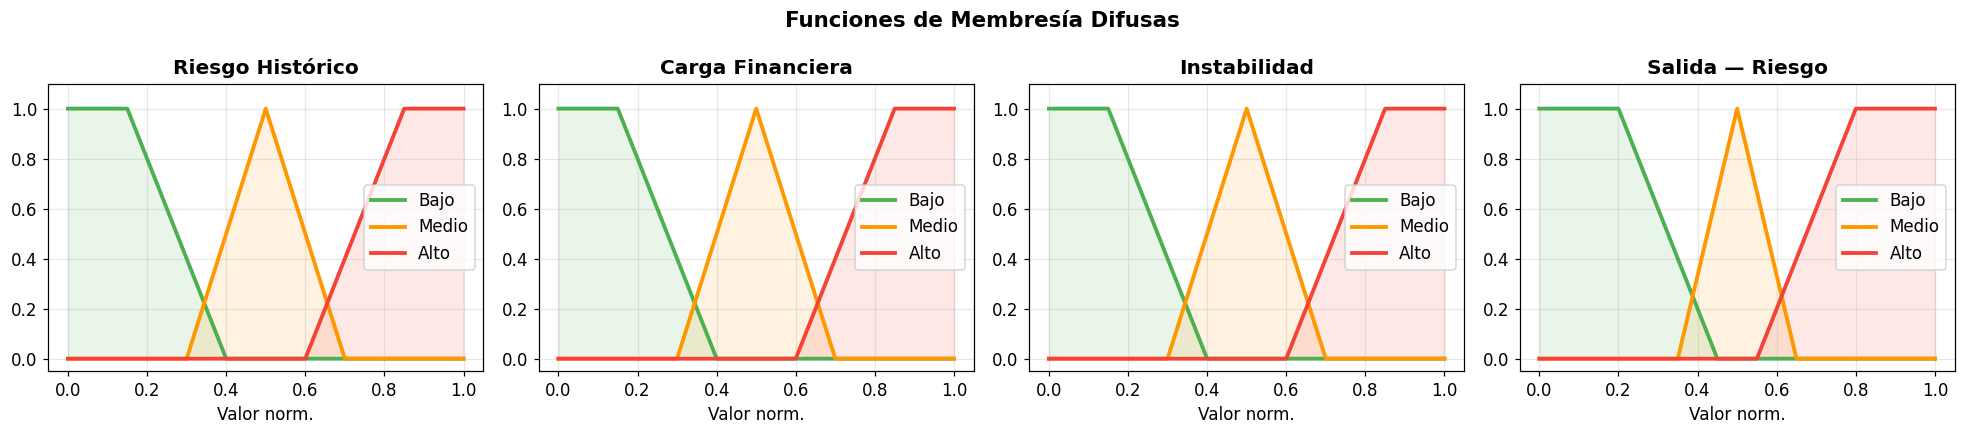


=== Tabla Comparativa ===


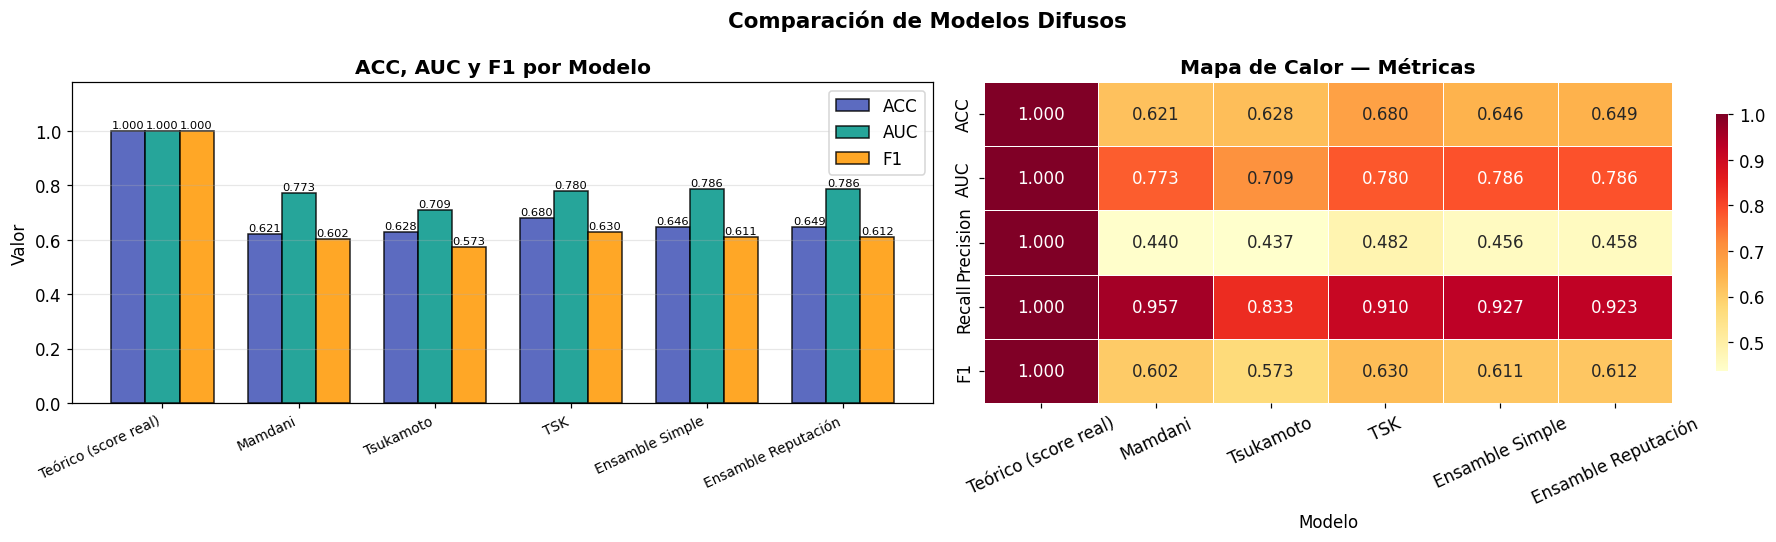


=== Curvas ROC y Distribución de Scores ===


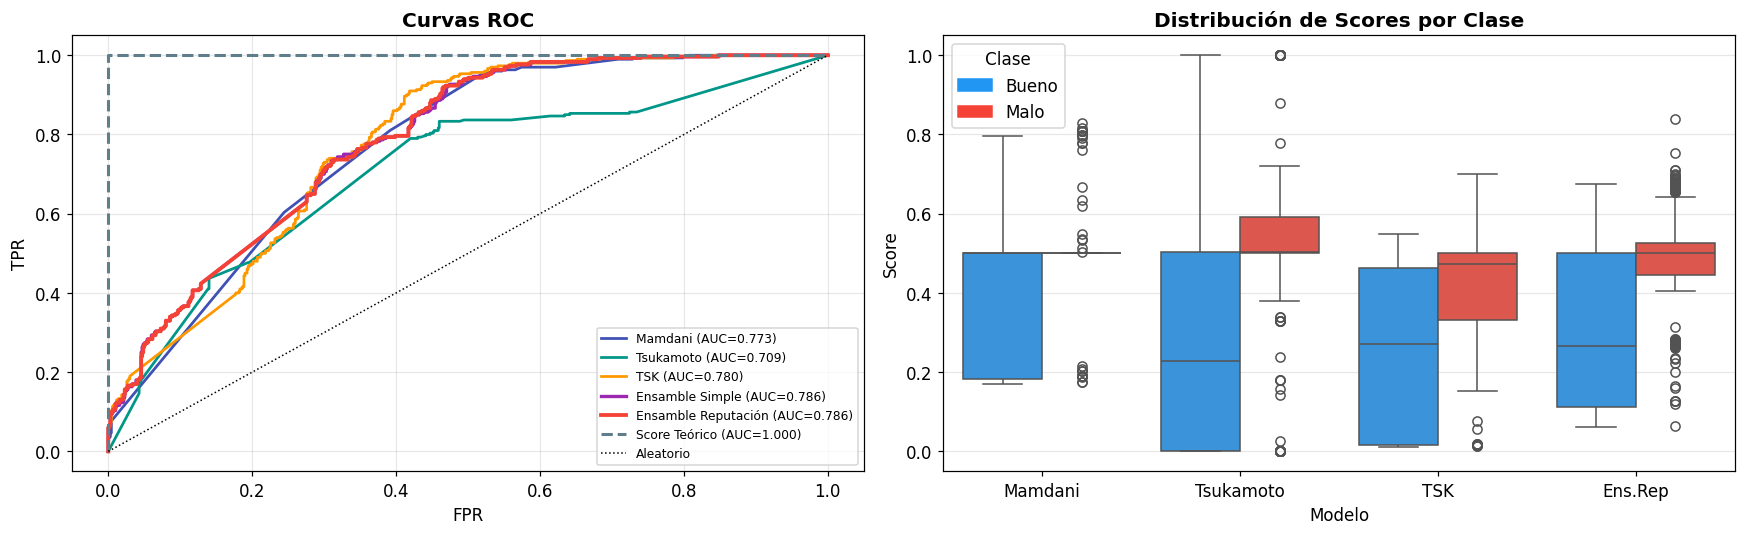


=== Matrices de Confusión ===


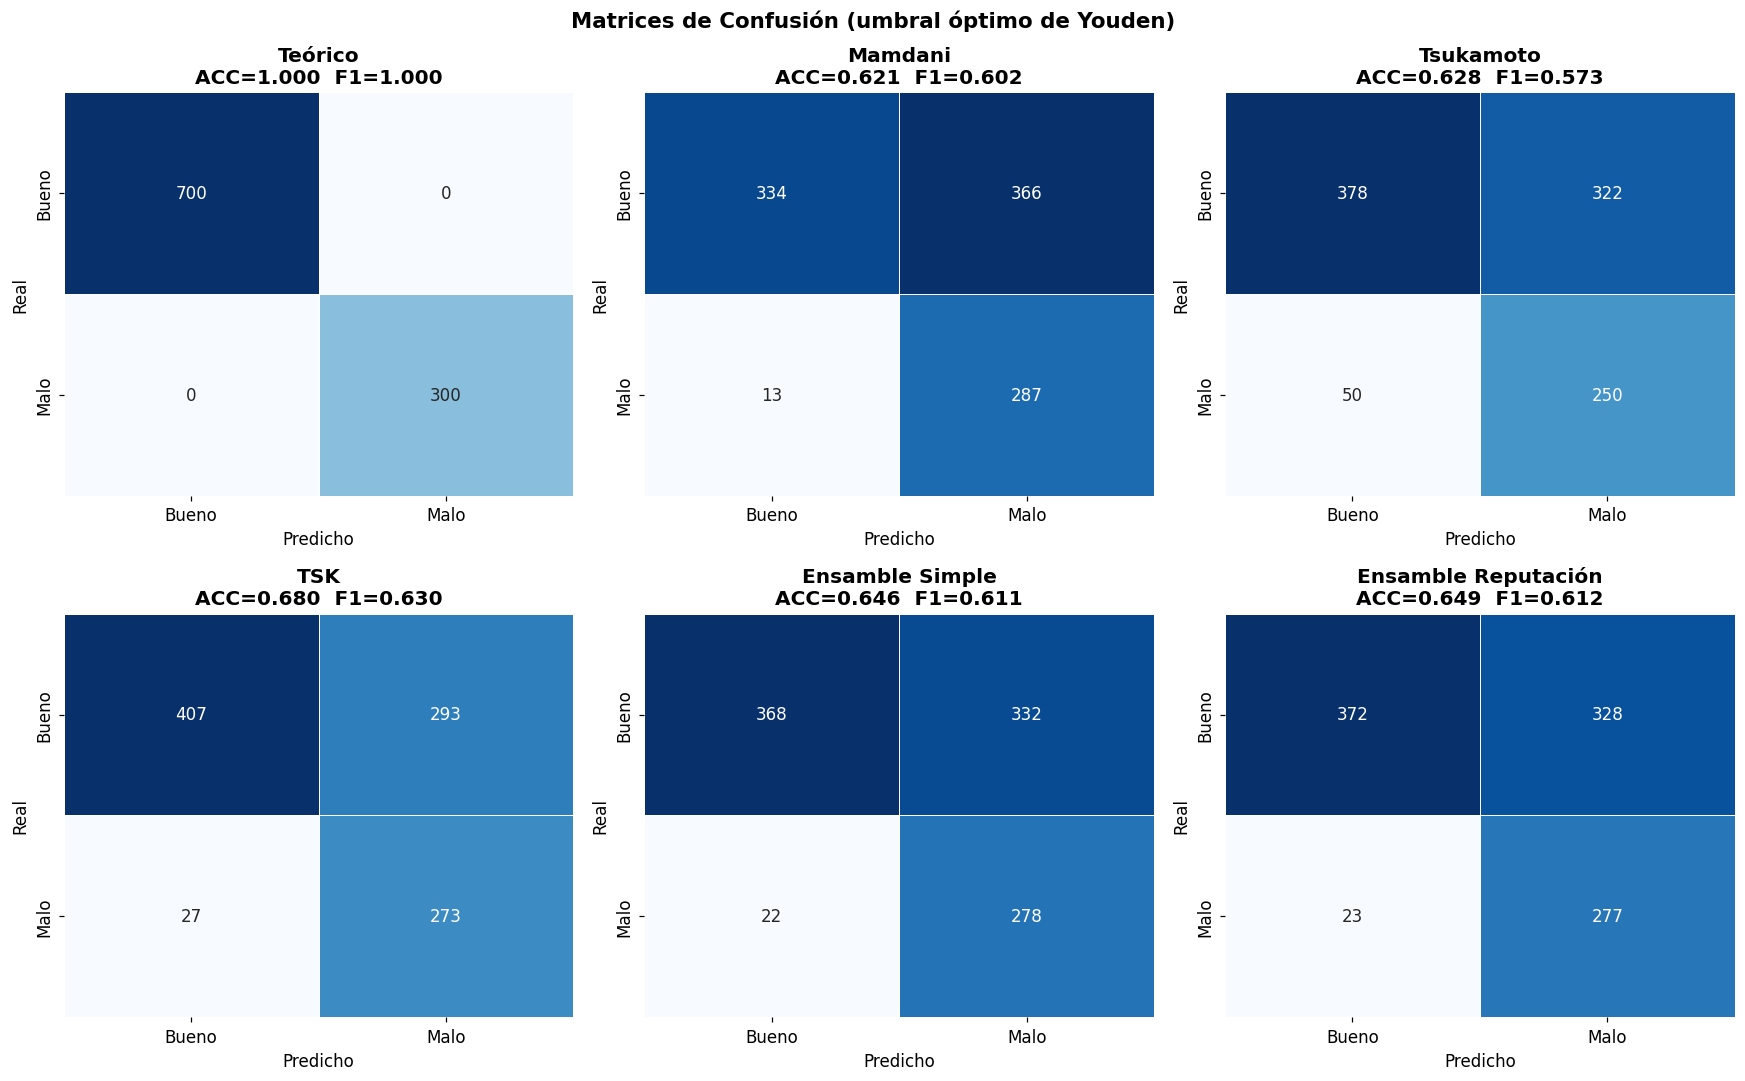


=== Pesos de Reputación ===


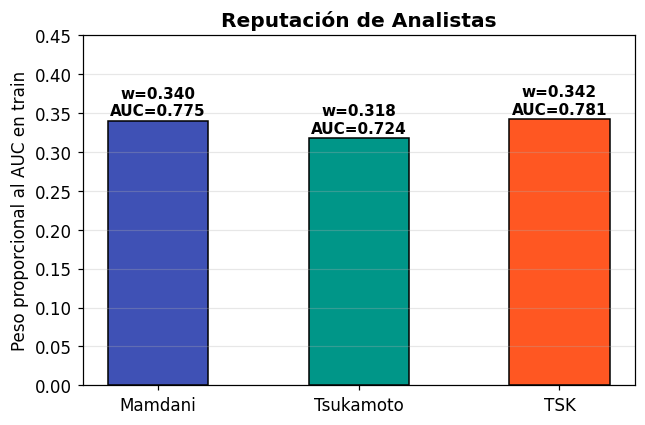


=== Análisis de Perfiles Extremos ===


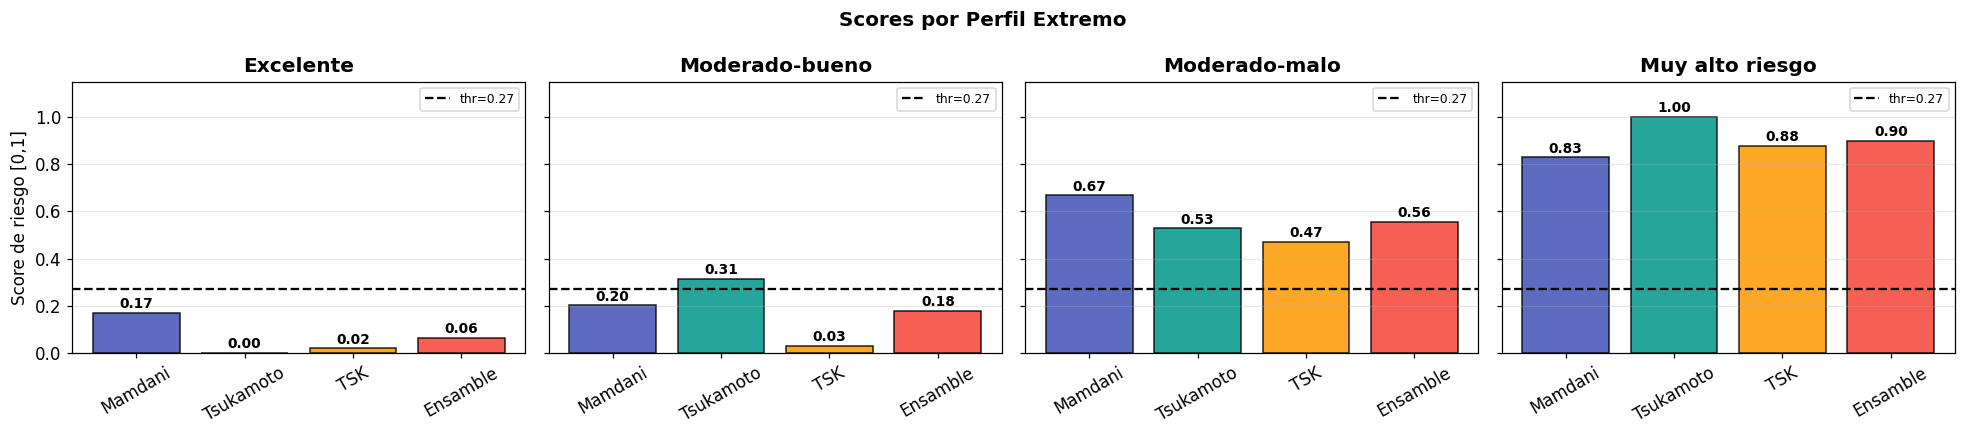

In [15]:

figuras = [
    ('membership_functions.png', 'Funciones de Membresía'),
    ('comparative_table.png', 'Tabla Comparativa'),
    ('roc_scores.png', 'Curvas ROC y Distribución de Scores'),
    ('confusion_matrices.png', 'Matrices de Confusión'),
    ('agent_reputation.png', 'Pesos de Reputación'),
    ('profile_analysis.png', 'Análisis de Perfiles Extremos'),
]

for archivo, titulo in figuras:
    print(f'\n=== {titulo} ===')
    display(Image(archivo))